In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Untitled form (Responses) - Form Responses 1.csv to Untitled form (Responses) - Form Responses 1.csv


In [ ]:
import pandas as pd

df = pd.read_csv("Untitled form (Responses) - Form Responses 1.csv")
df.head()

,Timestamp,When do you usually study the most?,"On average, how many hours do you study per day?",What is your current GPA?,What is your current year of study?,How many hours do you sleep on average per night?,Do you believe your study time (day/night) affects your academic performance?
0,4/4/2026 23:30:31,Night (6 PM – 12 AM),1–2 hours,Below 2.0,Second Year,Less than 5 hours,Not sure
1,4/4/2026 23:34:31,Afternoon (12 PM – 6 PM),1–2 hours,2.0–2.5,Second Year,7–8 hours,Yes
2,4/4/2026 23:39:13,Night (6 PM – 12 AM),5+ hours,3.0–3.5,Second Year,6–7 hours,Yes
3,4/4/2026 23:40:14,Night (6 PM – 12 AM),1–2 hours,3.0–3.5,Second Year,5–6 hours,Yes
4,4/4/2026 23:40:44,Afternoon (12 PM – 6 PM),3–4 hours,3.0–3.5,Second Year,6–7 hours,Not sure


In [ ]:
df.columns = [
    "Timestamp",
    "StudyTime",
    "StudyHours",
    "GPA",
    "Year",
    "SleepHours",
    "Opinion"
]

print("Data loaded successfully! Here are the first 5 rows:")
df.head()

Data loaded successfully! Here are the first 5 rows:


,Timestamp,StudyTime,StudyHours,GPA,Year,SleepHours,Opinion
0,4/4/2026 23:30:31,Night (6 PM – 12 AM),1–2 hours,Below 2.0,Second Year,Less than 5 hours,Not sure
1,4/4/2026 23:34:31,Afternoon (12 PM – 6 PM),1–2 hours,2.0–2.5,Second Year,7–8 hours,Yes
2,4/4/2026 23:39:13,Night (6 PM – 12 AM),5+ hours,3.0–3.5,Second Year,6–7 hours,Yes
3,4/4/2026 23:40:14,Night (6 PM – 12 AM),1–2 hours,3.0–3.5,Second Year,5–6 hours,Yes
4,4/4/2026 23:40:44,Afternoon (12 PM – 6 PM),3–4 hours,3.0–3.5,Second Year,6–7 hours,Not sure


In [31]:
# Create dictionaries to map your Google Form text ranges to number midpoints
gpa_map = {
    'Below 2.0': 1.75,
    '2.0–2.5': 2.25,
    '2.5–3.0': 2.75,
    '3.0–3.5': 3.25,
    '3.5–4.0': 3.75
}

# Keep these the same
study_map = {
    'Less than 1 hour': 0.5,
    '1–2 hours': 1.5,
    '3–4 hours': 3.5,
    '5+ hours': 5.5
}

sleep_map = {
    'Less than 5 hours': 4.5,
    '5–6 hours': 5.5,
    '6–7 hours': 6.5,
    '7–8 hours': 7.5,
    'More than 8 hours': 8.5
}

df['GPA_Num'] = df['GPA'].map(gpa_map)
df['StudyHours_Num'] = df['StudyHours'].map(study_map)
df['SleepHours_Num'] = df['SleepHours'].map(sleep_map)

# Drop any rows that are completely missing numeric data
df = df.dropna(subset=['GPA_Num', 'StudyHours_Num', 'SleepHours_Num'])

print("Data cleaning complete! Ranges converted to numbers.")

Data cleaning complete! Ranges converted to numbers.


In [ ]:
print("--- DESCRIPTIVE STATISTICS ---")
print(f"Mean GPA: {df['GPA_Num'].mean():.2f}")
print(f"Median GPA: {df['GPA_Num'].median()}")
print(f"Mode GPA: {df['GPA_Num'].mode()[0]}")
print("------------------------------")
print(f"Mean Study Hours: {df['StudyHours_Num'].mean():.2f}")
print(f"Median Study Hours: {df['StudyHours_Num'].median()}")
print(f"Mode Study Hours: {df['StudyHours_Num'].mode()[0]}")
print("------------------------------")
print(f"Mean Sleep Hours: {df['SleepHours_Num'].mean():.2f}")
print(f"Median Sleep Hours: {df['SleepHours_Num'].median()}")
print(f"Mode Sleep Hours: {df['SleepHours_Num'].mode()[0]}")

--- DESCRIPTIVE STATISTICS ---
Mean GPA: 2.80
Median GPA: 3.25
Mode GPA: 3.25
------------------------------
Mean Study Hours: 3.00
Median Study Hours: 3.5
Mode Study Hours: 3.5
------------------------------
Mean Sleep Hours: 6.63
Median Sleep Hours: 6.5
Mode Sleep Hours: 6.5


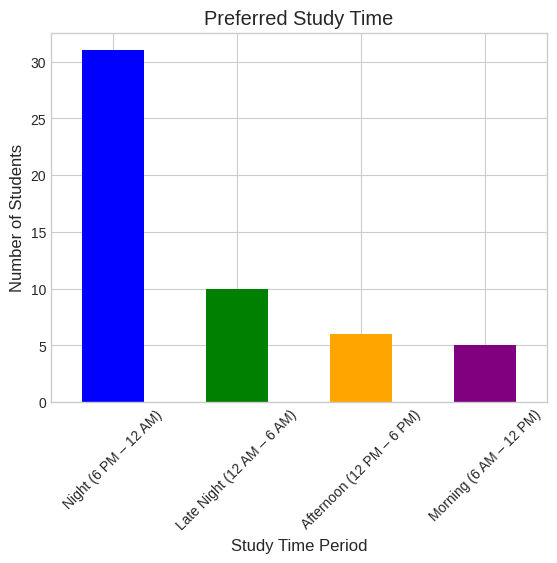

In [ ]:
# Count how many students chose each study time
study_counts = df["StudyTime"].value_counts()

# Create a basic bar chart
study_counts.plot(kind='bar', color=['blue', 'green', 'orange', 'purple'])

# Add simple labels
plt.title("Preferred Study Time")
plt.xlabel("Study Time Period")
plt.ylabel("Number of Students")
plt.xticks(rotation=45) # Rotates the text so it fits
plt.show()

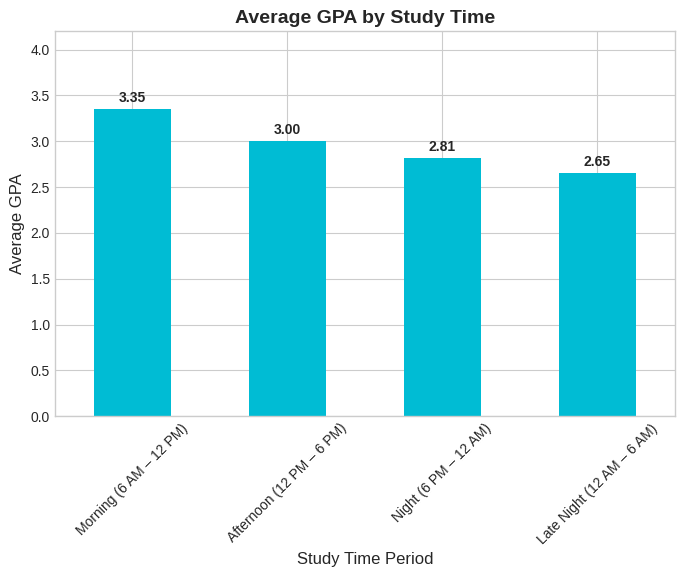

In [32]:
import matplotlib.pyplot as plt
# Calculate average GPA
gpa_avg = df.groupby("StudyTime")["GPA_Num"].mean().sort_values(ascending=False)

# Create the chart
ax = gpa_avg.plot(kind='bar', color='#00BCD4', figsize=(8,5))

# Add the numbers on top, formatted to 2 decimal places (like 3.35)
ax.bar_label(ax.containers[0], fmt='%.2f', padding=3, fontweight='bold')

plt.title("Average GPA by Study Time", fontsize=14, fontweight='bold')
plt.xlabel("Study Time Period")
plt.ylabel("Average GPA")
plt.ylim(0, 4.2) # Make room for the numbers on top
plt.xticks(rotation=45)
plt.show()

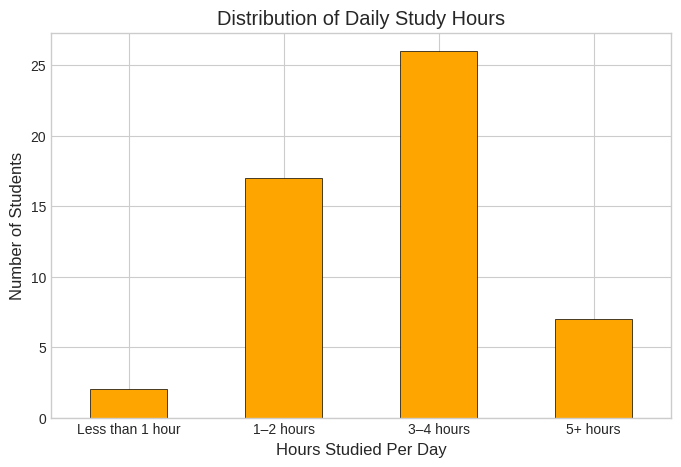

In [ ]:
# Create a list of the exact text categories in the correct logical order
study_order = ['Less than 1 hour', '1–2 hours', '3–4 hours', '5+ hours']

# Count the exact text answers and put them in that order
study_counts = df["StudyHours"].value_counts().reindex(study_order)

# Create a simple bar chart
study_counts.plot(kind='bar', color='orange', edgecolor='black', figsize=(8,5))

plt.title("Distribution of Daily Study Hours")
plt.xlabel("Hours Studied Per Day")
plt.ylabel("Number of Students")
plt.xticks(rotation=0) # Keeps the text straight so it is easy to read
plt.show()

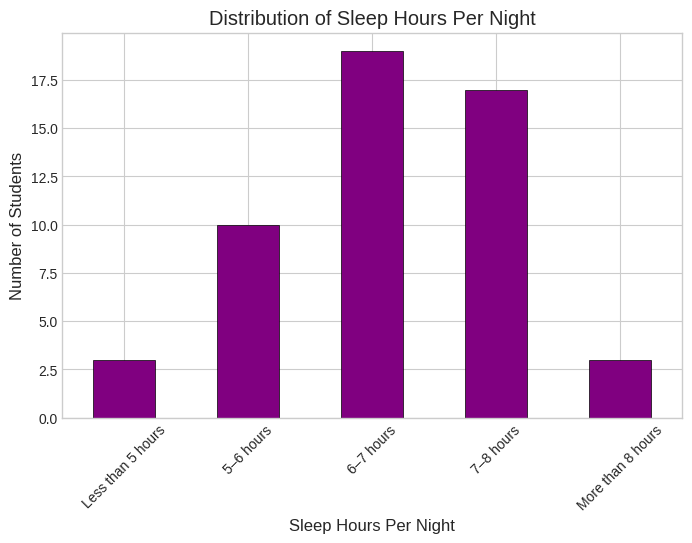

In [ ]:
# Create a list of the exact text categories in the correct logical order
sleep_order = ['Less than 5 hours', '5–6 hours', '6–7 hours', '7–8 hours', 'More than 8 hours']

# Count the exact text answers and put them in that order
sleep_counts = df["SleepHours"].value_counts().reindex(sleep_order)

# Create a simple bar chart
sleep_counts.plot(kind='bar', color='purple', edgecolor='black', figsize=(8,5))

plt.title("Distribution of Sleep Hours Per Night")
plt.xlabel("Sleep Hours Per Night")
plt.ylabel("Number of Students")
plt.xticks(rotation=45) # Rotates the text slightly so the long words fit
plt.show()

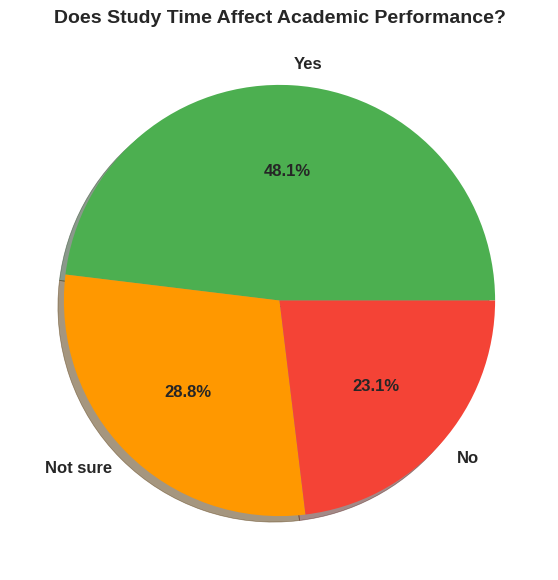

In [ ]:
# Count the answers
opinion_counts = df["Opinion"].value_counts()

# Create a beautiful pie chart with a shadow and clear percentages
opinion_counts.plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=['#4CAF50', '#FF9800', '#F44336'],
    figsize=(7,7),
    textprops={'fontsize': 12, 'weight': 'bold'},
    shadow=True
)

plt.title("Does Study Time Affect Academic Performance?", fontsize=14, fontweight='bold')
plt.ylabel("") # Hide the side label
plt.show()